# Notebook 1: Repository-Level Evaluation

**Goal:** Explain what happened for a single target repository.

**Inputs:** `evaluation_attempts.csv`, `evaluation_candidates.csv`, `generated_tests.csv`, `failure_cases.csv`

**RQs addressed:** RQ1, RQ2, RQ3, RQ7, RQ8, RQ9

In [1]:
# repo_name is injected by papermill when running via `analysis repo-report`.
# When running interactively this cell is a no-op and the notebook uses all repos.
if 'repo_name' not in dir():
    repo_name = None

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.normalize import build_candidate_summary
from analysis.plots import (
    outcome_funnel,
    stacked_outcome_bar,
    metric_delta_distribution,
    before_after_slope,
    cost_vs_improvement_scatter,
    failure_category_bar,
)

sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
FAILURE_DIR = DATA_DIR / 'failures'
REQUIRED_FILES = ['evaluation_attempts.csv', 'evaluation_candidates.csv']
missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing required analysis CSVs in {DATA_DIR}: {missing}')

attempts   = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv')
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv')
gen_tests  = pd.read_csv(DATA_DIR / 'generated_tests.csv') if (DATA_DIR / 'generated_tests.csv').exists() else pd.DataFrame()
failures   = pd.read_csv(FAILURE_DIR / 'failure_cases.csv') if (FAILURE_DIR / 'failure_cases.csv').exists() else pd.DataFrame()

# Select repository
repo_name injected by papermill single-repo report mode.

Running interactively with repo_name=None uses first repo in the dataset.

In [3]:

if repo_name and repo_name in attempts['repo_name'].values:
    REPO_NAME  = repo_name
    REPO_OWNER = attempts.loc[attempts['repo_name'] == REPO_NAME, 'repo_owner'].iloc[0]
else:
    if repo_name:
        print(f'[warn] repo_name={repo_name!r} not found â€” falling back to first repo.')
    _first = attempts[['repo_owner', 'repo_name']].drop_duplicates().iloc[0]
    REPO_OWNER = _first['repo_owner']
    REPO_NAME  = _first['repo_name']

COMMIT_HASH = None   # None = any commit

mask = (attempts['repo_owner'] == REPO_OWNER) & (attempts['repo_name'] == REPO_NAME)
if COMMIT_HASH:
    mask &= attempts['commit_hash'] == COMMIT_HASH

repo_attempts   = attempts[mask].copy()
repo_candidates = candidates[candidates['repo_name'] == REPO_NAME].copy()
print(f'Repository:       {REPO_OWNER}/{REPO_NAME}')
print(f'Attempts in repo: {len(repo_attempts)}')
print(f'Candidates:       {len(repo_candidates)}')

Repository:       consulthunter/TestMap-Example
Attempts in repo: 3
Candidates:       2


## 1. Repository Scope and Baseline

Records the repository identifier and commit hash, and reports the pre-existing coverage and mutation scores as the baseline against which all deltas are measured.


In [4]:
# Baseline coverage and mutation scores, candidate count, project count
print(repo_attempts[['repo_owner', 'repo_name', 'commit_hash']].drop_duplicates())
print('\nCoverage before (median):', repo_attempts['coverage_before'].median())
print('Mutation score before (median):', repo_attempts['mutation_score_before'].median())

      repo_owner        repo_name                               commit_hash
0  consulthunter  TestMap-Example  867ab17d3141bc0e6d696486bd8edb67546c00d1

Coverage before (median): 0.6521739130434783
Mutation score before (median): 22.22222222222222


## 2. Lane Outcome Funnels

Shows how many attempts cleared each pipeline stage for each lane:

| Stage | Meaning |
|---|---|
| total | All attempts |
| produced_change | Generated output (no generation failure) |
| build_passed | Output compiled successfully |
| tests_passed | Generated tests ran and passed (VEP + VLI) |
| validated | Tests passed **and** metrics improved >= noise floor (VEP only) |

The gap between each bar is the count lost at that stage, which localises where each lane primarily fails.

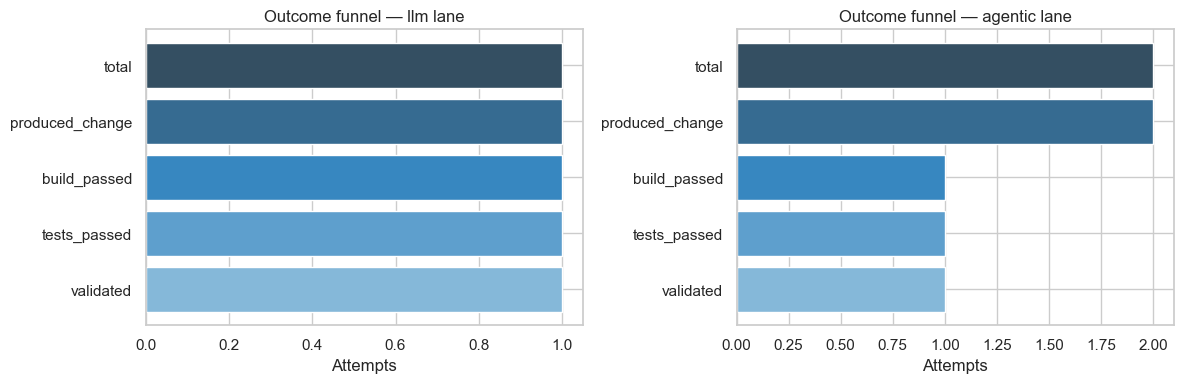

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
outcome_funnel(repo_attempts, lane='llm',     ax=axes[0])
outcome_funnel(repo_attempts, lane='agentic', ax=axes[1])
plt.tight_layout()
plt.show()

## 3. Candidate-Level Results

Collapses attempts to one row per (candidate, lane) using the best attempt selection rule (validated success > highest coverage_delta > first). This is the unit of analysis for the primary lane comparison.

`any_validated_success` uses the broad definition (VEP or VLI). `validated_evidence_positive_count` and `validated_low_impact_count` show how many attempts reached each outcome, separating tests that improved metrics from those that merely passed.


In [6]:
display_cols = [c for c in [
    'candidate_key', 'lane', 'any_validated_success',
    'validated_evidence_positive_count', 'validated_low_impact_count',
    'best_coverage_delta', 'best_mutation_delta', 'attempt_count'
] if c in repo_candidates.columns]
repo_candidates[display_cols].sort_values('any_validated_success', ascending=False).head(20)


,candidate_key,lane,any_validated_success,validated_evidence_positive_count,validated_low_impact_count,best_coverage_delta,best_mutation_delta,attempt_count
0,consulthunter|TestMap-Example|867ab17d3141bc0e...,llm,True,1,0,0.086957,2.777778,1
2,consulthunter|TestMap-Example|867ab17d3141bc0e...,agentic,True,1,0,0.347826,30.555556,2


## 4. Generated Test Volume and Quality

Per-test view: how many tests each attempt produced (agents often produce several) and the
structural quality of the generated tests (CC, MI, SLOC, coupling, test-smell count). The
baseline-vs-generated comparison is in Section 14.

Generated tests in this repo: 14
Volume (tests per attempt):


,tests_per_attempt_mean,tests_per_attempt_max,total_tests
lane,,,
agentic,6.5,8,13
llm,1.0,1,1


Generated test quality (median by lane):


,generated_test_cc,generated_test_mi,generated_test_sloc,generated_test_coupling,generated_test_smell_count
lane,,,,,
agentic,2.0,62.0,28.0,8.0,1.0
llm,2.0,63.0,19.0,7.0,1.0


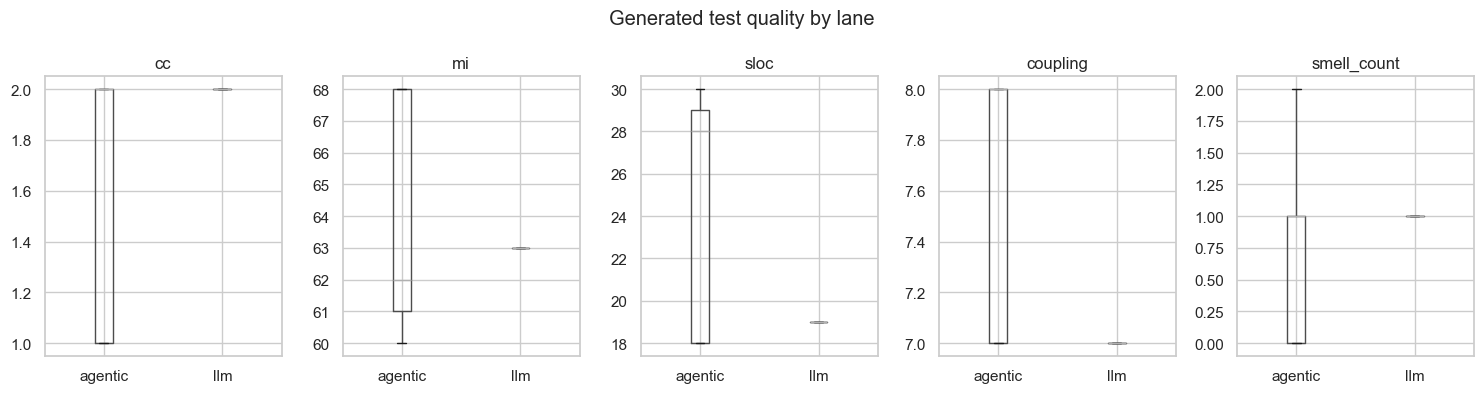

In [7]:
if not gen_tests.empty:
    repo_tests = gen_tests[gen_tests.get('repo_name', pd.Series()) == REPO_NAME]
    print(f'Generated tests in this repo: {len(repo_tests)}')
    if len(repo_tests):
        if 'attempt_id' in repo_tests.columns and 'lane' in repo_tests.columns:
            vol = (repo_tests.groupby(['lane', 'attempt_id']).size()
                   .groupby('lane').agg(['mean', 'max', 'sum']))
            vol.columns = ['tests_per_attempt_mean', 'tests_per_attempt_max', 'total_tests']
            print('Volume (tests per attempt):')
            display(vol.round(2))
        qcols = [c for c in ['generated_test_cc', 'generated_test_mi', 'generated_test_sloc',
                             'generated_test_coupling', 'generated_test_smell_count']
                 if c in repo_tests.columns]
        if qcols:
            print('Generated test quality (median by lane):')
            display(repo_tests.groupby('lane')[qcols].median().round(2))
            fig, axes = plt.subplots(1, len(qcols), figsize=(3 * len(qcols), 4))
            if len(qcols) == 1:
                axes = [axes]
            for ax, c in zip(axes, qcols):
                repo_tests.boxplot(column=c, by='lane', ax=ax)
                ax.set_title(c.replace('generated_test_', ''))
                ax.set_xlabel('')
            plt.suptitle('Generated test quality by lane')
            plt.tight_layout()
            plt.show()
else:
    print('No generated_tests.csv available.')

## 5. Coverage and Mutation Movement

Slope chart of before -> after metric values per attempt; the mean overlay shows the typical direction. Includes all attempts -- failed attempts that modified nothing appear as flat lines.

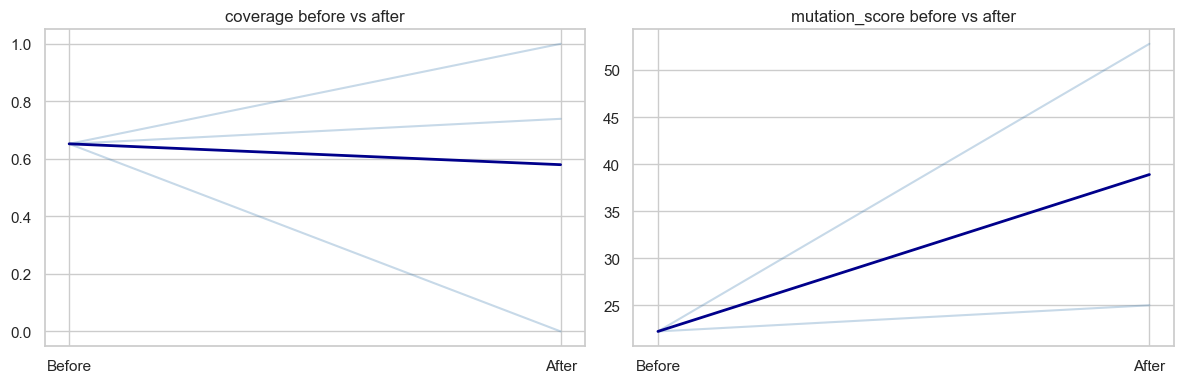

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before_after_slope(repo_attempts, 'coverage_before', 'coverage_after', ax=axes[0])
before_after_slope(repo_attempts, 'mutation_score_before', 'mutation_score_after', ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Cost and Runtime

Scatter plots of resource use (wall-clock time, and `effective_tokens` -- LLM cumulative chain vs agentic total run) against the two metric deltas, coloured by lane. Followed by per-lane duration. Lane-fair token totals are in Section 16.

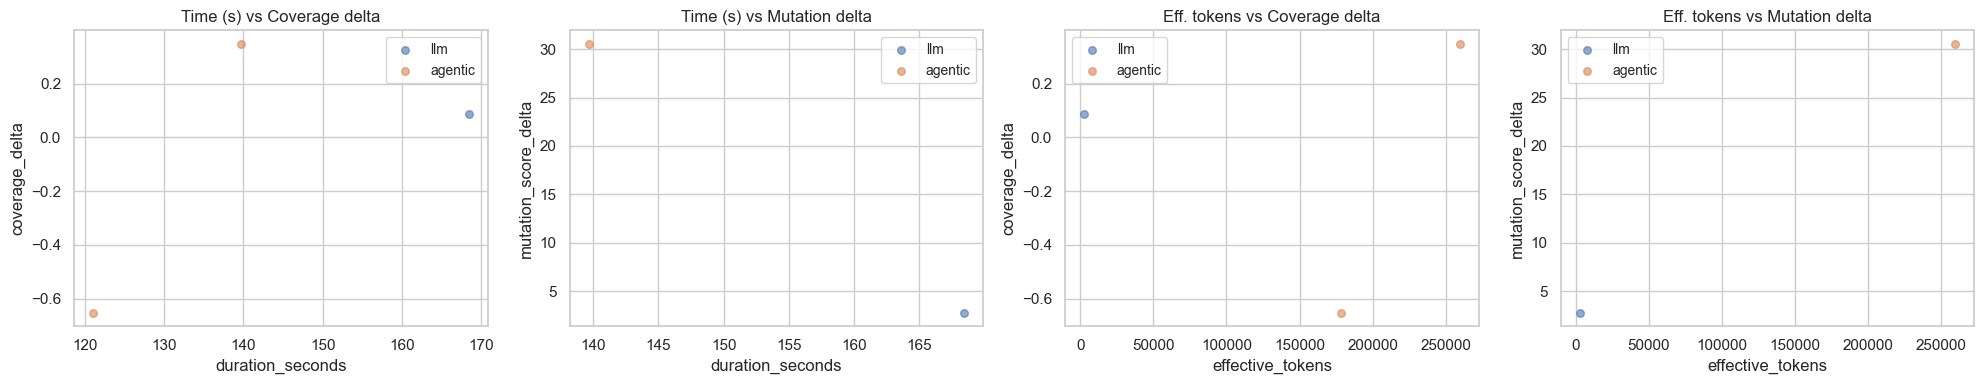

             median         sum
lane                           
agentic  130.309799  260.619599
llm      168.467166  168.467166


In [9]:
if 'duration_seconds' in repo_attempts.columns:
    pairs = [
        ('duration_seconds', 'coverage_delta',       'Time (s) vs Coverage delta'),
        ('duration_seconds', 'mutation_score_delta', 'Time (s) vs Mutation delta'),
        ('effective_tokens', 'coverage_delta',       'Eff. tokens vs Coverage delta'),
        ('effective_tokens', 'mutation_score_delta', 'Eff. tokens vs Mutation delta'),
    ]
    available = [(x, y, t) for x, y, t in pairs
                 if x in repo_attempts.columns and y in repo_attempts.columns]
    if available:
        fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
        if len(available) == 1:
            axes = [axes]
        for ax, (x_col, y_col, title) in zip(axes, available):
            cost_vs_improvement_scatter(repo_attempts, x_col, y_col, 'lane', ax=ax)
            ax.set_title(title)
        plt.tight_layout()
        plt.show()

# Per-lane duration (lane-fair token totals are in Section 16, candidate-level)
if 'duration_seconds' in repo_attempts.columns:
    print(repo_attempts.groupby('lane')['duration_seconds'].agg(['median', 'sum']))

## 7. Agentic Change Footprint

What the agentic lane modified beyond the target test file. `changed_files_count` is always present; the per-type breakdown (`production_files_changed`, `test_files_changed`, `project_files_changed`, `deleted_files_count`) is exported only by post-footprint-change runs and skipped when absent (as in this pilot). Production-file changes mean the tool altered non-test code.

,count,mean,std,min,25%,50%,75%,max
changed_files_count,2.0,1.5,0.71,1.0,1.25,1.5,1.75,2.0
test_files_changed,2.0,1.5,0.71,1.0,1.25,1.5,1.75,2.0
production_files_changed,2.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0
project_files_changed,2.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0
deleted_files_count,2.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0


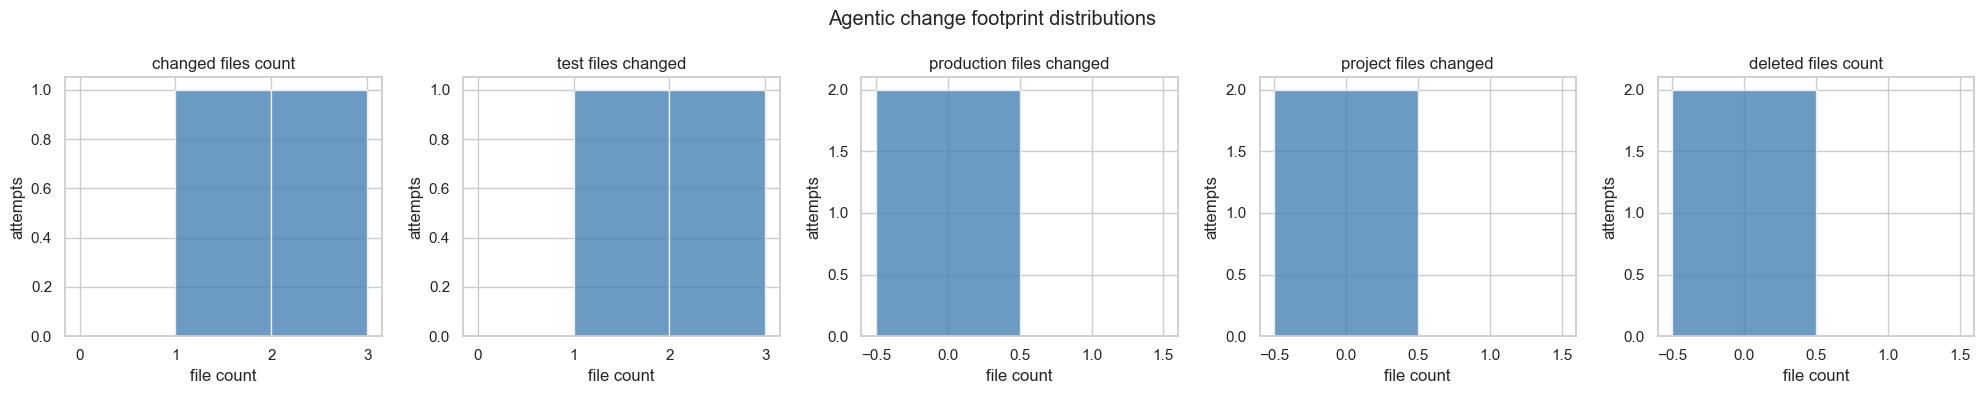


Production-file change rate by tool:
tool_id
codex     0.0
gemini    0.0
Name: production_change_rate, dtype: float64


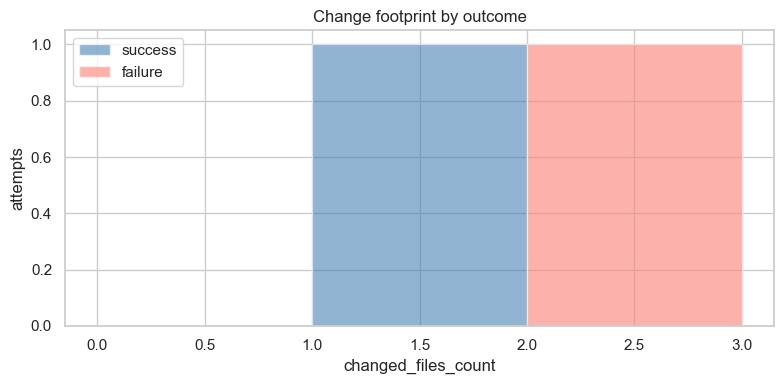

In [10]:
agentic = repo_attempts[repo_attempts['lane'] == 'agentic']
footprint_cols = [c for c in [
    'changed_files_count', 'test_files_changed',
    'production_files_changed', 'project_files_changed', 'deleted_files_count',
] if c in agentic.columns]

if not footprint_cols:
    print('No footprint columns available.')
else:
    display(agentic[footprint_cols].describe().T.round(2))

    # Footprint distributions
    fig, axes = plt.subplots(1, len(footprint_cols), figsize=(4 * len(footprint_cols), 4))
    if len(footprint_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, footprint_cols):
        vals = agentic[col].dropna()
        if len(vals) == 0:
            ax.set_visible(False)
            continue
        max_val = int(vals.max())
        bins = list(range(max_val + 2)) if max_val >= 1 else [-0.5, 0.5, 1.5]
        ax.hist(vals, bins=bins, color='steelblue', alpha=0.8, edgecolor='white')
        ax.set_title(col.replace('_', ' '))
        ax.set_xlabel('file count')
        ax.set_ylabel('attempts')
    plt.suptitle('Agentic change footprint distributions')
    plt.tight_layout()
    plt.show()

    # Production-change rate by tool
    if 'production_files_changed' in agentic.columns and 'tool_id' in agentic.columns:
        prod_rate = (
            agentic.groupby('tool_id')
            .apply(lambda g: (g['production_files_changed'].fillna(0) > 0).mean())
            .rename('production_change_rate')
        )
        print('\nProduction-file change rate by tool:')
        print(prod_rate.round(3))

    # Change footprint vs validation outcome
    if 'changed_files_count' in agentic.columns and 'validated_success' in agentic.columns:
        valid_fp = agentic.dropna(subset=['changed_files_count', 'validated_success'])
        if len(valid_fp) > 0:
            fig, ax = plt.subplots(figsize=(8, 4))
            max_val = int(valid_fp['changed_files_count'].max())
            bins = list(range(max_val + 2)) if max_val >= 1 else [-0.5, 0.5, 1.5]
            for success_val, label, color in [
                (True, 'success', 'steelblue'), (False, 'failure', 'salmon')
            ]:
                sub = valid_fp[valid_fp['validated_success'] == success_val]['changed_files_count']
                ax.hist(sub, bins=bins, alpha=0.6, label=label, color=color)
            ax.set_xlabel('changed_files_count')
            ax.set_ylabel('attempts')
            ax.set_title('Change footprint by outcome')
            ax.legend()
            plt.tight_layout()
            plt.show()


## 8. LLM Failure Taxonomy

Breaks down LLM lane failures by `failure_category` (generation, compile, test, application).

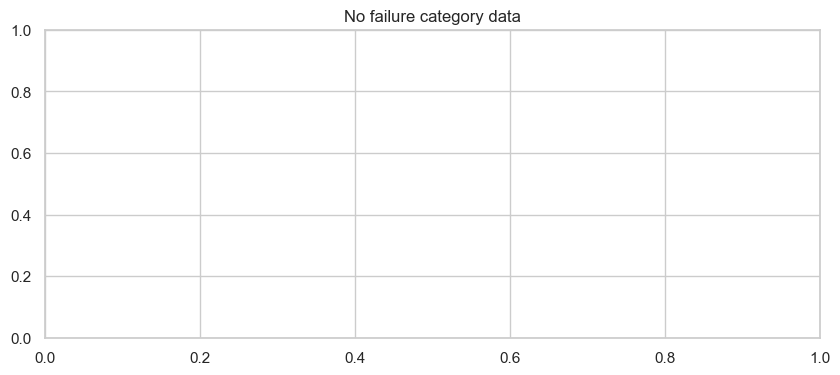

In [11]:
llm = repo_attempts[repo_attempts['lane'] == 'llm']
fig, ax = plt.subplots(figsize=(10, 4))
failure_category_bar(llm, lane_col='lane', category_col='failure_category', ax=ax)
plt.show()

## 9. Agentic Failure Outcomes

Stacked bar of `tool_validation_outcome` values per agentic tool. Shows the mix of Passed / TestsFailed / BuildFailed / TimedOut etc. per tool within this repository.


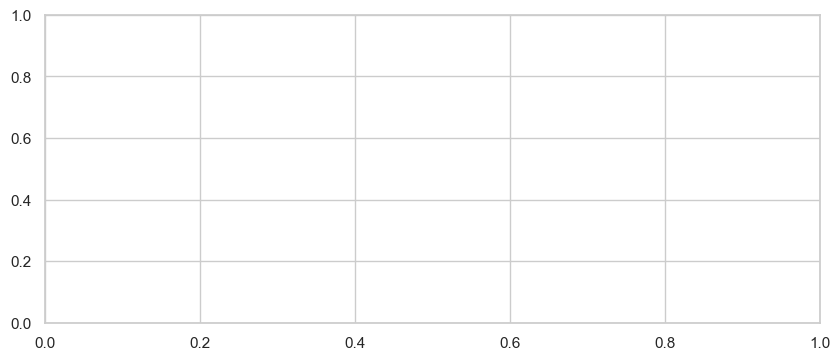

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
stacked_outcome_bar(agentic, group_col='tool_id', outcome_col='observed_outcome', ax=ax)
plt.show()

## 10. Qualitative Failure Case Sample

Lists the sampled failure cases for this repository, linked to their preliminary machine labels. These cases are the input for later open coding in Notebook 5. Run `python -m analysis export-failures ... --markdown` first.


In [13]:
if not failures.empty:
    repo_failures = failures[failures.get('repo_name', pd.Series()) == REPO_NAME]
    cols = [c for c in ['failure_case_id', 'lane', 'preliminary_failure_label', 'source_method_name', 'outcome_summary'] if c in repo_failures.columns]
    repo_failures[cols].head(10)
else:
    print('No failure_cases.csv available. Run: python -m analysis export-failures ...')

## 11. Repository Summary

Prints the full overview JSON for this repository: scope counts, outcome counts (broken down by VEP / VLI / FEP etc.), metric movement, cost, and data completeness. This is the machine-readable summary that backs the cross-repository overview in Notebook 2.


In [14]:
from analysis.summaries import build_overview
import json

overview = build_overview(repo_attempts)
print(json.dumps(overview, indent=2, default=str))

{
  "scope": {
    "repositories_evaluated": 1,
    "candidates_evaluated": 1,
    "total_attempts": 3,
    "llm_attempts": 1,
    "agentic_attempts": 2,
    "models_evaluated": 3,
    "tools_evaluated": 2
  },
  "generated_tests": {
    "generated_tests_total": 20,
    "generated_tests_llm": 1,
    "generated_tests_agentic": 19,
    "candidates_with_at_least_one_test": 1,
    "candidates_with_multiple_tests": 1
  },
  "outcomes": {
    "validated_successes": 2,
    "positive_impact_attempts": 2,
    "validated_evidence_positive_attempts": 2,
    "validated_low_impact_attempts": 0,
    "outcome_validatedevidencepositive_total": 2,
    "outcome_validatedevidencepositive_llm": 1,
    "outcome_validatedevidencepositive_agentic": 1,
    "outcome_validatedlowimpact_total": 0,
    "outcome_validatedlowimpact_llm": 0,
    "outcome_validatedlowimpact_agentic": 0,
    "outcome_failedevidencepositive_total": 0,
    "outcome_failedevidencepositive_llm": 0,
    "outcome_failedevidencepositive_agen

## 12. Outcome Classification

Authoritative outcome label per lane, as a counts table. `ValidatedLowImpact` (passed but no metric movement above the noise floor) appears as its own row when present in the data.

In [15]:
if 'outcome_classification' in repo_attempts.columns:
    counts = (repo_attempts
             .groupby(['outcome_classification', 'lane'])
             .size().unstack(fill_value=0))
    display(counts)
else:
    print('outcome_classification column not found.')

lane,agentic,llm
outcome_classification,,
ValidatedEvidencePositive,1,1
ValidationFailed,1,0


## 13. Source Method Characteristics

Distribution of structural metrics for the target source methods in this repository: cyclomatic complexity, maintainability index, SLOC, coupling. Characterises the difficulty profile of the evaluation candidates.


,count,mean,std,min,25%,50%,75%,max
source_method_cc,3.0,8.00,0.0,8.00,8.00,8.00,8.00,8.00
source_method_mi,3.0,64.00,0.0,64.00,64.00,64.00,64.00,64.00
source_method_coupling,3.0,3.00,0.0,3.00,3.00,3.00,3.00,3.00
source_method_dit,3.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00
source_method_sloc,3.0,36.00,0.0,36.00,36.00,36.00,36.00,36.00
source_method_baseline_coverage,3.0,0.65,0.0,0.65,0.65,0.65,0.65,0.65


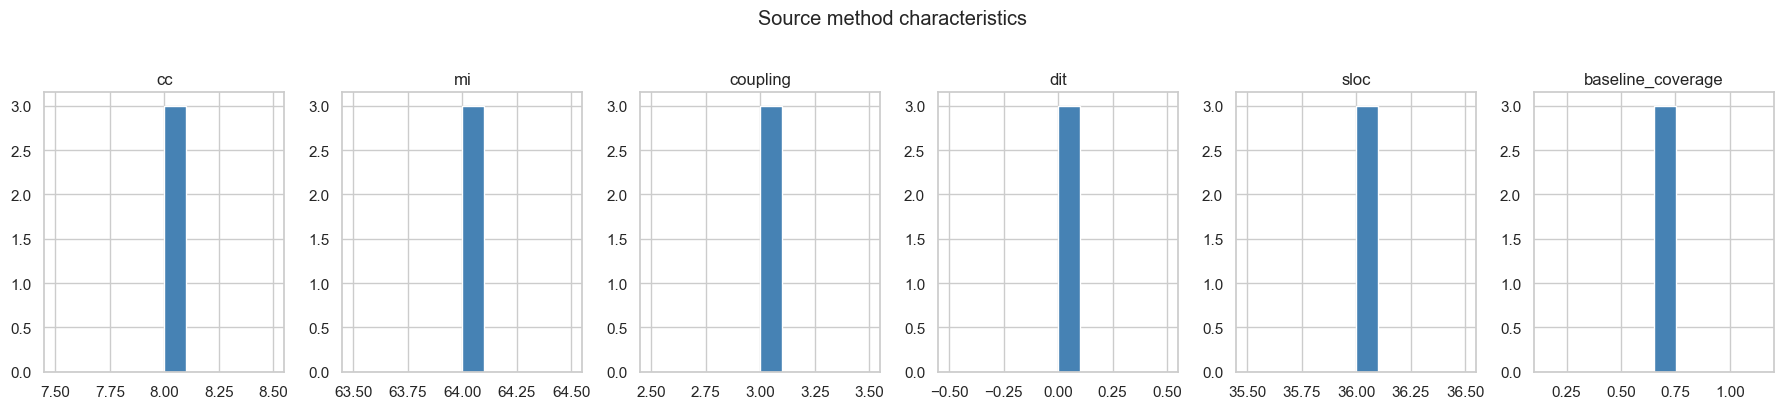

In [16]:
source_metric_cols = [c for c in [
    'source_method_cc', 'source_method_mi', 'source_method_coupling',
    'source_method_dit', 'source_method_sloc', 'source_method_baseline_coverage',
] if c in repo_attempts.columns]

if source_metric_cols:
    display(repo_attempts[source_metric_cols].describe().T.round(2))

    fig, axes = plt.subplots(1, len(source_metric_cols), figsize=(3 * len(source_metric_cols), 4))
    if len(source_metric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, source_metric_cols):
        repo_attempts[col].dropna().hist(bins=10, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(col.replace('source_method_', ''))
    plt.suptitle('Source method characteristics', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Source method metric columns not found in dataset.')

## 14. Code Metrics: Baseline Test vs Generated Test

Slope charts comparing structural metrics of the **baseline tests** (existing) against the **generated tests** (output). Each line is one attempt; the mean overlay shows the typical direction of transformation. Includes all attempts regardless of outcome.

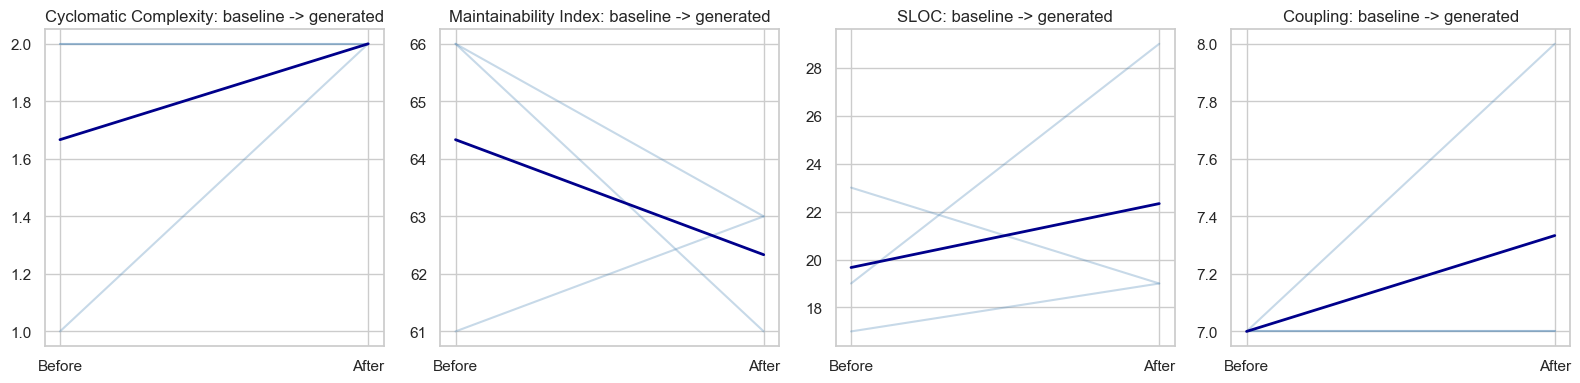

,baseline_median,generated_median,median_pct_change
metric,,,
Cyclomatic Complexity,2.0,2.0,0.00
Maintainability Index,66.0,63.0,-4.55
SLOC,19.0,19.0,11.76
Coupling,7.0,7.0,0.00


In [17]:
from analysis.plots import before_after_slope
import numpy as np

metric_pairs = [
    ('baseline_test_cc',       'generated_test_cc',       'Cyclomatic Complexity'),
    ('baseline_test_mi',       'generated_test_mi',       'Maintainability Index'),
    ('baseline_test_sloc',     'generated_test_sloc',     'SLOC'),
    ('baseline_test_coupling', 'generated_test_coupling', 'Coupling'),
]
available_pairs = [(b, g, lbl) for b, g, lbl in metric_pairs
                   if b in repo_attempts.columns and g in repo_attempts.columns]

if available_pairs:
    fig, axes = plt.subplots(1, len(available_pairs), figsize=(4 * len(available_pairs), 4))
    if len(available_pairs) == 1:
        axes = [axes]
    for ax, (before_col, after_col, label) in zip(axes, available_pairs):
        before_after_slope(repo_attempts, before_col, after_col, ax=ax)
        ax.set_title(f'{label}: baseline -> generated')
    plt.tight_layout()
    plt.show()

# Summary table: baseline vs generated median + signed median % change per metric
rows = []
for before_col, after_col, label in available_pairs:
    b = pd.to_numeric(repo_attempts[before_col], errors='coerce')
    g = pd.to_numeric(repo_attempts[after_col], errors='coerce')
    pct = ((g - b) / b.replace(0, np.nan)) * 100   # per-attempt signed % change
    rows.append({
        'metric': label,
        'baseline_median': b.median(),
        'generated_median': g.median(),
        'median_pct_change': pct.median(),
    })
if rows:
    display(pd.DataFrame(rows).set_index('metric').round(2))

## 15. Test Smell Analysis

Counts and categorises test smell instances in baseline (existing) and generated test files. A generated smell count higher than the baseline suggests the tool is introducing quality debt alongside the new test.


Baseline: total smell instances=2, attempts with smells=1/3
Generated: total smell instances=3, attempts with smells=3/3


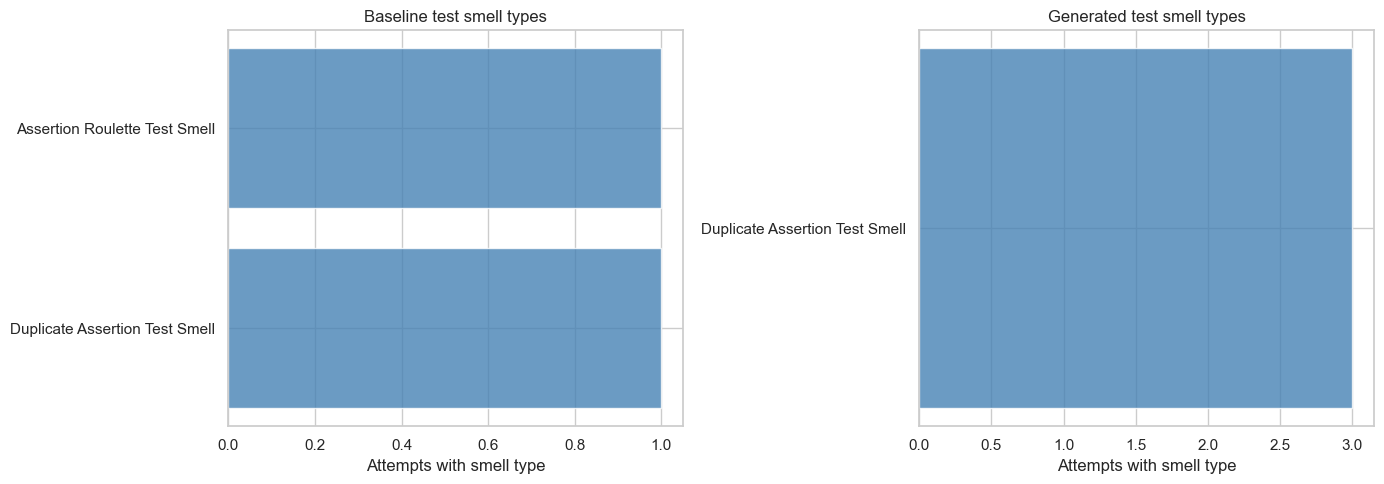

In [18]:
from analysis.plots import smell_type_breakdown

for count_col, types_col, label in [
    ('baseline_test_smell_count',  'baseline_test_smell_types',  'Baseline'),
    ('generated_test_smell_count', 'generated_test_smell_types', 'Generated'),
]:
    if count_col in repo_attempts.columns:
        total = repo_attempts[count_col].fillna(0).sum()
        with_smells = (repo_attempts[count_col].fillna(0) > 0).sum()
        print(f'{label}: total smell instances={int(total)}, attempts with smells={with_smells}/{len(repo_attempts)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
smell_type_breakdown(repo_attempts, 'baseline_test_smell_types',  ax=axes[0])
axes[0].set_title('Baseline test smell types')
smell_type_breakdown(repo_attempts, 'generated_test_smell_types', ax=axes[1])
axes[1].set_title('Generated test smell types')
plt.tight_layout()
plt.show()

## 16. Timing Breakdown

Left chart is a **stacked** bar of median generation vs validation duration per lane -- the two phases sum to total attempt time, so stacking shows the decomposition. Right chart is **grouped** bars of baseline vs generated test execution time -- a comparison, not a sum, so the bars sit side by side.

Token usage compares the LLM lane's `cumulative_tokens` (running total across the repair chain) against the agentic lane's `total_tokens` (the whole agent run; agentic `cumulative_tokens` is not populated). Per candidate, LLM cost = max cumulative over its chain; agentic cost = total_tokens.

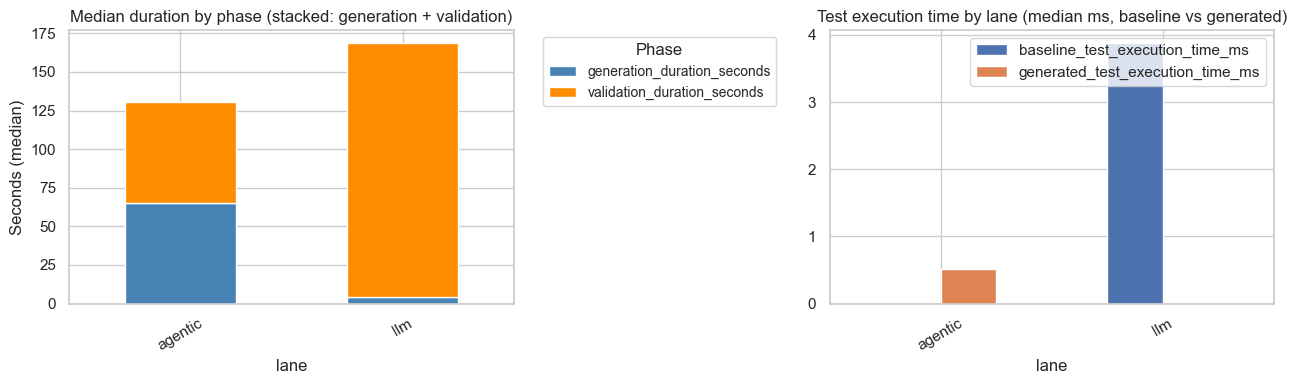

Effective tokens per candidate (LLM = cumulative chain, agentic = total run):


,sum,median,count
lane,,,
agentic,438145.0,438145.0,1
llm,10820.0,5410.0,2


In [19]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(repo_attempts, group_col='lane', ax=axes[0])
axes[0].set_title('Median duration by phase (stacked: generation + validation)')

exec_cols = [c for c in ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
             if c in repo_attempts.columns]
if exec_cols:
    repo_attempts.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Test execution time by lane (median ms, baseline vs generated)')
    axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Lane-fair token cost (candidate-level effective_tokens):
# LLM = max cumulative over the repair chain; agentic = total run.
if 'effective_tokens' in candidates.columns and 'lane' in candidates.columns:
    print('Effective tokens per candidate (LLM = cumulative chain, agentic = total run):')
    display(candidates.groupby('lane')['effective_tokens'].agg(['sum', 'median', 'count']))